In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Week-9

**Note to Learners**:

- For questions that involve plotting, just enter $0$ as the answer in the portal.


## Dataset

Run the cell given below to generate the data-matrix $\mathbf{X}$, which is of shape $(n, d)$, where $n$ denotes the number of samples and $d$ denotes the number of features.

**Do not edit this cell.**

In [2]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=50, n_features=2, n_informative = 2, n_redundant = 0, n_clusters_per_class = 1, flip_y = 0, class_sep = 3, random_state=20)

## Problem 1
How many samples are there in the dataset?



In [3]:
num_samples = X.shape[0]
print(f"Number of samples in the dataset: {num_samples}")

Number of samples in the dataset: 50


## Problem 2

How many features are there in the dataset?


In [4]:
num_features = X.shape[1]
print(f"Number of features in the dataset: {num_features}")

Number of features in the dataset: 2


## Problem 3
In the target vector $y$, replace all occurrences of 0 with -1.

How many unique classes are there in the target vector?



In [5]:
y[y == 0] = -1
unique_classes = np.unique(y)
num_unique_classes = len(unique_classes)
print(f"Target vector after replacing 0 with -1: {y}")
print(f"Unique classes in the target vector: {unique_classes}")
print(f"Number of unique classes: {num_unique_classes}")

Target vector after replacing 0 with -1: [ 1  1  1  1  1  1  1 -1 -1  1 -1 -1 -1  1 -1 -1  1  1 -1  1 -1  1 -1 -1
  1 -1  1 -1  1  1 -1  1 -1  1 -1  1  1 -1 -1 -1 -1  1  1 -1 -1 -1 -1  1
  1 -1]
Unique classes in the target vector: [-1  1]
Number of unique classes: 2


## Problem 4
Plot the data keepig first feature on the x-axis and the second feature on the y-axis. Plot the data points belonging to each class in different colors. Does the data seem linearly separable?

[MCQ]

**Options:**

(a) Yes

(b) No



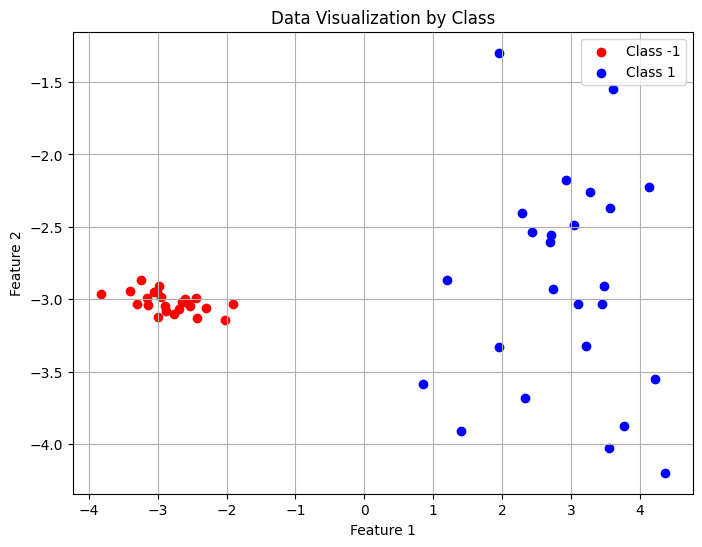

Based on the plot, the data appears to be linearly separable: (a) Yes


In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Data Visualization by Class')
plt.legend()
plt.grid(True)
plt.show()

print("Based on the plot, the data appears to be linearly separable: (a) Yes")

## Problem 5

Initialize w to be a zero vector, with shape equal to the number of features in the data.

Iterate over each data point $x$ in $X$ one by one (in the same sequence as present in $X$). For each data point, compute the value of $w^Tx$. If $w^Tx \ge 0$, predict positive class for $x$, else predict the negative class.

If prediction does not match the actual class label, update the weight vector as per the following update rule:
$$w_{new} = w_{old} + xy$$ where $x$ is the data point and $y$ is the actual label of $x$.

Run the above for 10 epochs (iterations), but stop if there are no weight updates in an epoch.

In which iteration, does the number of weight updates becomes zero for the first time?

[NAT]
**Options**

(a) 1

(b) 2

(c) 3

(d) 5



In [7]:
w = np.zeros(num_features)

num_epochs = 10
first_zero_update_epoch = -1

for epoch in range(1, num_epochs + 1):
    num_updates = 0
    for i in range(num_samples):
        x_i = X[i]
        y_i = y[i]

        # Compute w^T x
        prediction_score = np.dot(w.T, x_i)

        # Predict class
        predicted_class = 1 if prediction_score >= 0 else -1

        # Update weight vector if prediction is incorrect
        if predicted_class != y_i:
            w = w + x_i * y_i
            num_updates += 1

    print(f"Epoch {epoch}: Number of weight updates = {num_updates}")

    if num_updates == 0:
        first_zero_update_epoch = epoch
        break

if first_zero_update_epoch != -1:
    print(f"The number of weight updates became zero for the first time in Epoch: {first_zero_update_epoch}")
else:
    print("Weight updates did not become zero within the specified number of epochs.")

Epoch 1: Number of weight updates = 2
Epoch 2: Number of weight updates = 0
The number of weight updates became zero for the first time in Epoch: 2


## Problem 6
Plot the vector w and the decision boundary thus obtained.



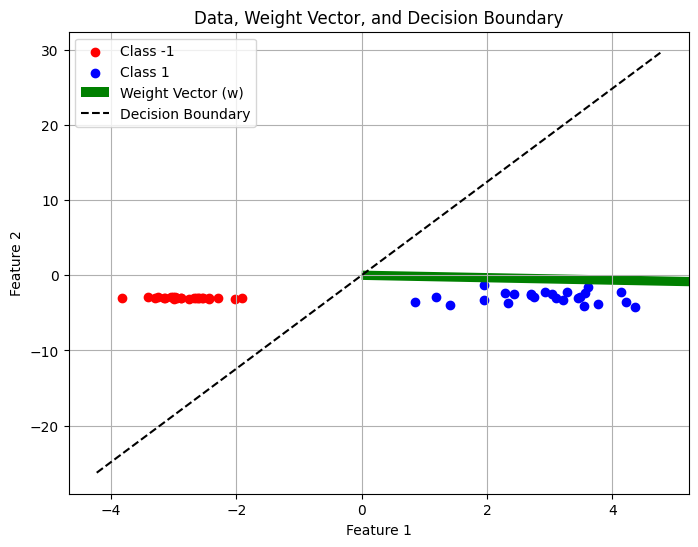

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1')

# Plot the weight vector w
plt.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.015, label='Weight Vector (w)')

# Plot the decision boundary
# The decision boundary is w[0]*x1 + w[1]*x2 = 0, so x2 = (-w[0]/w[1])*x1
if w[1] != 0:
    x1_min, x1_max = plt.xlim()
    x_db = np.linspace(x1_min, x1_max, 100)
    y_db = (-w[0] / w[1]) * x_db
    plt.plot(x_db, y_db, 'k--', label='Decision Boundary')
else: # Handle vertical decision boundary case if w[1] is zero
    plt.axvline(x=0, color='k', linestyle='--', label='Decision Boundary') # This assumes w[0] is not zero

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Data, Weight Vector, and Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()

## Problem 7
What is the value of loss using the weight vector obtained earlier?  


In [9]:
num_misclassified = 0
for i in range(num_samples):
    x_i = X[i]
    y_i = y[i]
    prediction_score = np.dot(w.T, x_i)
    predicted_class = 1 if prediction_score >= 0 else -1
    if predicted_class != y_i:
        num_misclassified += 1

print(f"Number of misclassified samples (loss): {num_misclassified}")

Number of misclassified samples (loss): 0


## Problem 8
Now use the following data set, replace occurrences of 0 with -1 and visualize.

**Do not edit the following cell.**



In [ ]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=50, n_features=2, n_informative = 2, n_redundant = 0, n_clusters_per_class = 1, flip_y = 0.1, class_sep = 2, random_state=20)

In [10]:
y[y == 0] = -1
print(f"Target vector after replacing 0 with -1 in new dataset: {y}")

Target vector after replacing 0 with -1 in new dataset: [ 1  1  1  1  1  1  1 -1 -1  1 -1 -1 -1  1 -1 -1  1  1 -1  1 -1  1 -1 -1
  1 -1  1 -1  1  1 -1  1 -1  1 -1  1  1 -1 -1 -1 -1  1  1 -1 -1 -1 -1  1
  1 -1]


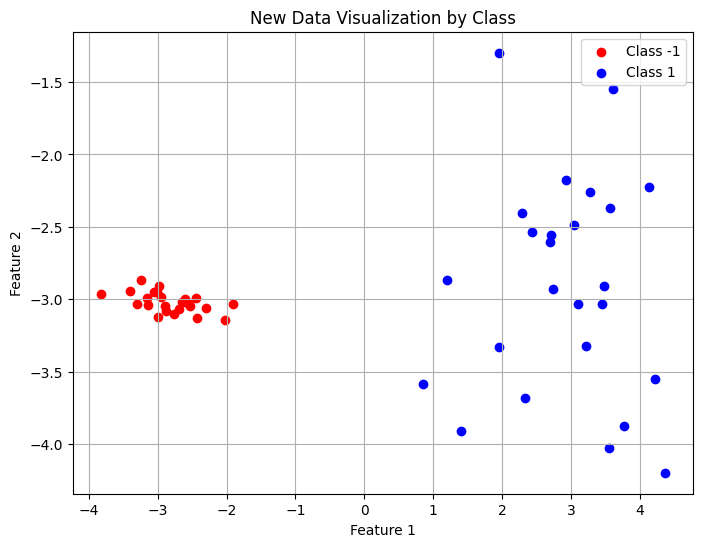

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('New Data Visualization by Class')
plt.legend()
plt.grid(True)
plt.show()

## Problem 9

Apply the Perceptron code again.

What is the number of weight updates performed in epoch 10?



In [12]:
w_new_data = np.zeros(num_features)

num_epochs = 10
updates_in_epoch_10 = 0

print("Applying Perceptron to new dataset:")
for epoch in range(1, num_epochs + 1):
    num_updates = 0
    for i in range(num_samples):
        x_i = X[i]
        y_i = y[i]

        prediction_score = np.dot(w_new_data.T, x_i)
        predicted_class = 1 if prediction_score >= 0 else -1

        if predicted_class != y_i:
            w_new_data = w_new_data + x_i * y_i
            num_updates += 1

    print(f"Epoch {epoch}: Number of weight updates = {num_updates}")

    if epoch == 10:
        updates_in_epoch_10 = num_updates

print(f"\nNumber of weight updates performed in epoch 10: {updates_in_epoch_10}")

w = w_new_data # Update the global w for Problem 10

Applying Perceptron to new dataset:
Epoch 1: Number of weight updates = 2
Epoch 2: Number of weight updates = 0
Epoch 3: Number of weight updates = 0
Epoch 4: Number of weight updates = 0
Epoch 5: Number of weight updates = 0
Epoch 6: Number of weight updates = 0
Epoch 7: Number of weight updates = 0
Epoch 8: Number of weight updates = 0
Epoch 9: Number of weight updates = 0
Epoch 10: Number of weight updates = 0

Number of weight updates performed in epoch 10: 0


## Problem 10
Visualize the weight vector and the decision boundary.



## Problem 11
What is the value of loss using the weight vector obtained in the 10th epoch?

In [14]:
num_misclassified_new_data = 0
for i in range(num_samples):
    x_i = X[i]
    y_i = y[i]
    prediction_score = np.dot(w.T, x_i)
    predicted_class = 1 if prediction_score >= 0 else -1
    if predicted_class != y_i:
        num_misclassified_new_data += 1

print(f"Number of misclassified samples (loss) for new data: {num_misclassified_new_data}")

Number of misclassified samples (loss) for new data: 0


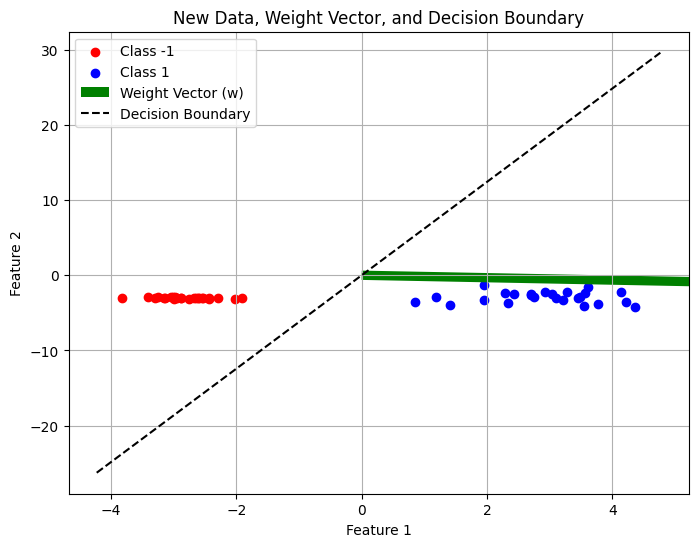

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1')

# Plot the weight vector w
plt.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.015, label='Weight Vector (w)')

# Plot the decision boundary
# The decision boundary is w[0]*x1 + w[1]*x2 = 0, so x2 = (-w[0]/w[1])*x1
if w[1] != 0:
    x1_min, x1_max = plt.xlim()
    x_db = np.linspace(x1_min, x1_max, 100)
    y_db = (-w[0] / w[1]) * x_db
    plt.plot(x_db, y_db, 'k--', label='Decision Boundary')
else: # Handle vertical decision boundary case if w[1] is zero
    plt.axvline(x=0, color='k', linestyle='--', label='Decision Boundary') # This assumes w[0] is not zero

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('New Data, Weight Vector, and Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()